# <a href="https://thetahat.ru/courses/ad" target="_top">Введение в анализ данных</a>
## Домашнее задание 10. Анализ вакансий.


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Правила оформления теоретических задач:**

* Решения необходимо оформить в виде $\LaTeX$ в markdown-ячейках. Иные способы (в т.ч. фотографии) не принимаются.
* Если вы не знаете $\LaTeX$, используйте ИИ-инструменты для оформления черновика решения. Примеры были показаны на лекции 2 по ИИ-инструментам.
* **В решениях поясняйте, чем вы пользуетесь**, хотя бы кратко.
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `...`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.


---

**Баллы за задание:**

<b><a href="#Сложная-часть" style="text-decoration: none;"><font color="orange">Сложная часть</font></a></b> (учитывается только в основной части курса, необходимо на "отл"):
* Задача 1 &mdash; 70 баллов

<b><a href="#Факультативная-часть" style="text-decoration: none;"><font color="green">Факультативная часть</font></a></b> (учитывается только в факультативной части курса):
* Задача 2 &mdash; 30 баллов
* Задача 3 &mdash; 70 баллов

**Внимание!** Указанные баллы являются бонусными. Они не учитываются в максимальных суммах баллов в знаменателе при вычислении процента выполненных заданий. Но все полученные вами баллы будут учтены в числителе. Тем самым, выполняя или не выполняя домашку, вы не сможете понизить оценку, но сможете ее повысить.

In [ ]:
# Bot check

# HW_ID: fpmi_ad10
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
pip install openpyxl

In [2]:
!pip install folium

In [3]:
!pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 25.1 MB/s eta 0:00:00


In [31]:
import requests
from time import sleep
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from time import sleep
from tqdm import tqdm  # для визуализации прогресса
from pandas.io.formats.excel import ExcelFormatter
import openpyxl
import random
import folium
from folium.plugins import HeatMap
import contextily as ctx
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import HTML
from IPython.display import IFrame, display
import os

sns.set(style="whitegrid", font_scale=1.3, palette="Set2")


Второй курс &mdash; самое время задуматься о будущей профессии и проанализировать существующие предложения. Дело тут даже не в том, чтобы найти интересную стажировку. В первую очередь сейчас стоит подумать о том, в какую сторону развиваться дальше. Например, если вы хотите работать в какой-либо конкретной профессии, то наверняка стоит развивать какие-то определенные навыки, и даже выбрать подходящую кафедру. Анализ существующих вакансий поможет определить, какие навыки вам нужны.

**Внимание!**
В первую очередь задание призвано помочь вам понять, какие навыки стоит развивать, и может быть даже выбрать подходящую кафедру. Однако, не стоит идти на работу/стажировку раньше времени. Даже только летнюю, абсолютное большинство людей не могут работать круглый год без перерыва. У всех из вас 3 курс достаточно нагруженный, а на DS-потоке нагрузка с первой недели сентября. И если вы идете на стажировку, то каникул у вас может просто не остаться. Даже если вам сейчас/летом/в сентябре кажется "я же справлюсь", к ноябрю-декабрю с большой вероятностью вы выдохнетесь. Таких примеров *очень много*. Не все, кто-то успешно справляется совмещать работу и учебу, но таких *очень мало*. Берегите себя и свое здоровье :)

---

Задание предполагает вариативность исследуемых данных. Вы можете выбрать один из следующих вариантов.
1. Стандартный вариант &mdash; проанализировать вакансии на сайте <a target="_blank" href="https://hh.ru/">hh.ru</a> с использованием <a target="_blank" href="https://dev.hh.ru/">официального API</a>. Далее приведен пример работы с этим API. *Если вы не достаточно уверены в своих силах, рекомендуется выбрать этот вариант.*
2. Разобраться с API других сервисов по поиску вакансий, например, <a target="_blank" href="https://career.habr.com/">Хабр.Карьера</a> или <a target="_blank" href="https://www.superjob.ru/">SuperJob</a>.
3. Извлечение данных с помощью <a target="_top" href="https://thetahat.ru/files/ad/main/11/data_parsing.html#2.-Парсинг-HTML-напрямую">парсинга HTML напрямую</a> некоторых сайтов. Например, вы можете попробовать напрямую распарсить пул вакансий из тех источников, которые не предоставляют API. **Внимание! Обращайте внимание на пользовательские соглашения и на <a  target="_top" href="https://thetahat.ru/files/ad/main/11/data_parsing.html#Сбор-данных-из-открытых-источников">эти рекомендации</a>.**
4. Комбинирование нескольких подходов. В этом случае нужно понимать, как находить одинаковые вакансии из разных источников для избежания их двойного учета.
5. Можно также *дополнительно* брать архивные данные из недавнего прошлого, например, из <a target="_blank" href="https://boosters.pro/championship/HeadHunter/overview/description">этого соревнования</a>.

Перед выполнением задания ознакомьтесь с <a target="_top" href="https://thetahat.ru/courses/ad/main/11/data_parsing">материалом</a> о сборе данных из открытых источников.

Для получения максимального балла за задание достаточно выполнить все задание по стандартному варианту. Альтернативные варианты, даже более сложные, не дают больше баллов, чем максимальное количество баллов по стандартному варианту.

Работа в некоторой степени творческая, поэтому конкретные детали решения в основном остаются на усмотрение автора решения. Например, если в вакансии зарплата укзана "*от ...*" или  "*до ...*", то вы сами решаете, как это обрабатывать, но не забывайте про четкую аргументацию. Не забывайте также заглядывать в презентацию по выполнению и оформлению домашних заданий с занятия 2.

 ---
### Справка по работе с API сервиса hh.ru.   

<b><font color="red">Внимание!</font> При работе с API не забывайте делать паузы между запросами, чтобы не задудосить сервер. Если вас заблокируют, это не будет являться уважительной причиной переноса дедлайна.</b>

Мы будем работать только с вакансиями. Для этого не требуется регистрироваться и получать токен. Ниже приведен краткий пример работы с API. Подробное описание работы с вакансиями, включая параметры запросов и формат ответа можно почитать в <a target="_blank" href="https://github.com/hhru/api/blob/master/docs/vacancies.md#search">документации</a>.

Например, мы хотим найти вакансии по запросу `Data Scientist` в Москве. Тогда первую страницу поиска из 10 вакансий на страницу мы можем получить с запроса к API:

In [ ]:
URL = "https://api.hh.ru/vacancies"

params = {
    "text": "Data Scientist",
    "area": 1,
    "page": 0,
    "per_page": 10,
}

req = requests.get(URL, params)
data = json.loads(req.content.decode())

Если все прошло успешно, полученный словарь будет иметь следующие ключи

In [ ]:
data.keys()

dict_keys(['items', 'found', 'pages', 'page', 'per_page', 'clusters', 'arguments', 'fixes', 'suggests', 'alternate_url'])

Можем посмотреть на краткое описание первой вакансии

In [ ]:
data["items"][0]

{'id': '120576000',
 'premium': False,
 'name': 'Junior Data Scientist',
 'department': {'id': '201-201-tehprakt',
  'name': 'Kept, Технологическая практика'},
 'has_test': False,
 'response_letter_required': False,
 'area': {'id': '1', 'name': 'Москва', 'url': 'https://api.hh.ru/areas/1'},
 'salary': None,
 'salary_range': None,
 'type': {'id': 'open', 'name': 'Открытая'},
 'address': None,
 'response_url': None,
 'sort_point_distance': None,
 'published_at': '2025-05-15T11:02:45+0300',
 'created_at': '2025-05-15T11:02:45+0300',
 'archived': False,
 'apply_alternate_url': 'https://hh.ru/applicant/vacancy_response?vacancyId=120576000',
 'branding': {'type': 'MAKEUP', 'tariff': None},
 'show_logo_in_search': True,
 'show_contacts': False,
 'insider_interview': None,
 'url': 'https://api.hh.ru/vacancies/120576000?host=hh.ru',
 'alternate_url': 'https://hh.ru/vacancy/120576000',
 'relations': [],
 'employer': {'id': '201',
  'name': 'Kept (Кэпт)',
  'url': 'https://api.hh.ru/employers/201

Сколько всего найдено вакансий

In [ ]:
data["found"]

240

Количество страниц в результатах поиска

In [ ]:
data["pages"]

24

Из результатов можем сделать удобную таблицу, причем в дальнейшем можно оставить только те колонки, которые необходимы для анализа.

In [ ]:
df = pd.json_normalize(data["items"])
df.head()

,id,premium,name,has_test,response_letter_required,salary,salary_range,address,response_url,sort_point_distance,...,address.metro_stations,address.id,address.metro.station_name,address.metro.line_name,address.metro.station_id,address.metro.line_id,address.metro.lat,address.metro.lng,salary_range.frequency.id,salary_range.frequency.name
0,120576000,False,Junior Data Scientist,False,False,NaN,NaN,NaN,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,120605791,False,Data Scientist (Специалист по машинному обучению),False,False,NaN,NaN,NaN,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,120549501,False,Python-разработчик в Data team,False,False,NaN,NaN,NaN,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,120409712,False,Data Scientist (Специалист по анализу данных),False,False,NaN,NaN,NaN,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,120527165,False,Data Scientist,False,False,NaN,NaN,NaN,None,None,...,[],6153521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Для получения полного описания вакансии потребуется задать отдельный запрос, используя ее `id`.

In [ ]:
vacancy = df["id"].iloc[0]
vacancy_url = f"https://api.hh.ru/vacancies/{vacancy}"

req = requests.get(vacancy_url)
vacancy_info = json.loads(req.content.decode())

In [ ]:
vacancy_info

{'id': '120576000',
 'premium': False,
 'billing_type': {'id': 'standard', 'name': 'Стандарт'},
 'relations': [],
 'name': 'Junior Data Scientist',
 'insider_interview': None,
 'response_letter_required': False,
 'area': {'id': '1', 'name': 'Москва', 'url': 'https://api.hh.ru/areas/1'},
 'salary': None,
 'salary_range': None,
 'type': {'id': 'open', 'name': 'Открытая'},
 'address': None,
 'allow_messages': True,
 'experience': {'id': 'between1And3', 'name': 'От 1 года до 3 лет'},
 'schedule': {'id': 'remote', 'name': 'Удаленная работа'},
 'employment': {'id': 'full', 'name': 'Полная занятость'},
 'department': {'id': '201-201-tehprakt',
  'name': 'Kept, Технологическая практика'},
 'show_contacts': False,
 'contacts': None,
 'description': '<p>Kept – аудиторско-консалтинговая фирма, которая прежде была частью международной сети KPMG, но формально покинула ее 8 июня 2022 года. Мы проводим аудит финансовой отчетности, предоставляем услуги по улучшению показателей эффективности, разработк

---

### <font color="orange"><i>Сложная часть</i></font>

 ---
### Задача 1.   

Исследуем профессию Data Scientist. Найдите как можно больше вакансий по этой профессии в Москве. Учтите, что имеет смысл искать также по другим ключевым словам, например, `аналитик данных`.

In [ ]:
def smart_search():
    url = "https://api.hh.ru/vacancies"

    # Упрощенный поисковый запрос
    params = {
        "text": 'NAME:("дата аналитик" OR "Аналитик данных" OR "ML Engineer" OR "ML-инженер" OR "Data Scientist" OR "Data analyst") OR DESCRIPTION:("дата аналитик" OR ML* OR "ML Engineer" OR "ML-инженер" OR "Data Scientist" OR "Data analyst")',
        "page": 0,
        "area": 1,
        "per_page": 100,
        "order_by": "publication_time"
    }

    all_vacancies = []

    while True:
        try:
            response = requests.get(url, params=params)
            response.raise_for_status()
            data = response.json()

            # Просто добавляем все полученные результаты
            all_vacancies.extend(data['items'])

            # Проверка последней страницы
            if params["page"] >= data["pages"] - 1 or len(all_vacancies) >= 1799:
                break

            params["page"] += 1

            # Случайная задержка
            time.sleep(random.uniform(1.0, 1.3))

        except Exception as e:
            print(f"Ошибка: {e}")
            break

    return pd.json_normalize(all_vacancies)

# Запуск и проверка
df = smart_search()

# Анализ результатов
print(f"Всего найдено: {len(df)}")
print("Топ-5 вакансий:")
print(df[['name', 'employer.name']].head())

KeyboardInterrupt: 

В полученную выборку некоторые вакансии могли попасть несколько раз. Удалите дубликаты.

In [ ]:
df = df.drop_duplicates(subset='id', keep='first')
print(f"Уникальных вакансий: {len(df)}")

Уникальных вакансий: 1728


In [ ]:
print("Пример ID:", df['id'])

Пример ID: 0       119826698
1       120638339
2       120034572
3       118573575
4       119957298
          ...    
1725    118533908
1726    119600681
1727    119598745
1728    119596944
1729    119596883
Name: id, Length: 1728, dtype: object


Загрузите подробное описание каждой вакансии и создайте удобную для дальнейших действий таблицу данных.

In [ ]:
def get_vacancy_details(vacancy_id: str) -> dict:
    """Получение полного описания вакансии по ID"""
    url = f"https://api.hh.ru/vacancies/{vacancy_id}"
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Ошибка при получении вакансии {vacancy_id}: {str(e)}")
        return None

In [ ]:
def enrich_vacancies_data(df: pd.DataFrame) -> pd.DataFrame:
    """Добавление подробной информации к данным о вакансиях"""
    enriched_data = []

    with tqdm(total=len(df), desc="Обработка вакансий", unit="шт") as pbar:
        for _, row in df.iterrows():
            try:
                vacancy_id = row['id']
                details = get_vacancy_details(vacancy_id)

                if not details:
                    continue

                # Безопасное извлечение данных о зарплате
                salary = details.get('salary') or {}
                address = details.get('address') or {}
                metro = address.get('metro') or {}

                # Извлечение данных о формате работы
                work_format = details.get('work_format', [])
                working_days = details.get('working_days', [])
                working_hours = details.get('working_hours', [])
                work_schedule_by_days = details.get('work_schedule_by_days', [])
                employment_form = details.get('employment_form', {})

                record = {
                    'id': vacancy_id,
                    'name': details.get('name'),
                    'employer': (details.get('employer') or {}).get('name'),
                    'salary_from': salary.get('from'),
                    'salary_to': salary.get('to'),
                    'currency': salary.get('currency'),
                    'gross_net': 'gross' if salary.get('gross') else 'net',
                    'experience': (details.get('experience') or {}).get('name'),
                    'schedule': (details.get('schedule') or {}).get('name'),
                    'employment': (details.get('employment') or {}).get('name'),
                    'skills': ', '.join([s['name'] for s in (details.get('key_skills') or [])]),
                    'description': details.get('description'),
                    'metro_line': metro.get('line_name'),
                    'metro_station': metro.get('station_name'),
                    'published_at': details.get('published_at'),
                    'url': details.get('alternate_url'),
                    'key_skills': details.get('key_skills'),
                    'work_format': ', '.join([f['name'] for f in work_format]),
                    'working_days': ', '.join([d['name'] for d in working_days]),
                    'working_hours': ', '.join([h['name'] for h in working_hours]),
                    'work_schedule_by_days': ', '.join([s['name'] for s in work_schedule_by_days]),
                    'employment_form': employment_form.get('name')
                }
                enriched_data.append(record)

            except Exception as e:
                print(f"\nОшибка в вакансии {vacancy_id}: {str(e)}")

            finally:
                time.sleep(0.05)
                pbar.update(1)

    return pd.DataFrame(enriched_data)

In [ ]:
enriched_df_csv = enrich_vacancies_data(df)

# Сохранение результатов в csv
enriched_df_csv.to_csv('detailed_vacancies_csv.csv', index=False, encoding='utf-8-sig')

# Пример данных
print(f"\nСобрано данных: {len(enriched_df_csv)} вакансий")
print("Структура данных:")
print(enriched_df_csv.dtypes)
print("\nПример записи:")
print(enriched_df_csv.iloc[0])

Обработка вакансий: 100%|██████████| 1728/1728 [19:40<00:00,  1.46шт/s]



Собрано данных: 1728 вакансий
Структура данных:
id                        object
name                      object
employer                  object
salary_from              float64
salary_to                float64
currency                  object
gross_net                 object
experience                object
schedule                  object
employment                object
skills                    object
description               object
metro_line                object
metro_station             object
published_at              object
url                       object
key_skills                object
work_format               object
working_days              object
working_hours             object
work_schedule_by_days     object
employment_form           object
dtype: object

Пример записи:
id                                                               119826698
name                                               Старший бизнес-аналитик
employer                                     

In [ ]:
# параметры
enriched_df_csv.to_excel(
    'detailed_vacancies_xlsx.xlsx',
    index=False,
    engine='openpyxl',
    sheet_name='Вакансии',
    columns=[
        'name', 'employer', 'salary_from', 'salary_to', 'currency',
        'experience', 'skills', 'published_at', 'url'
    ]
)

# Функция для авто-ширины колонок
def auto_width_columns(writer, df, sheet_name):
    worksheet = writer.sheets[sheet_name]
    for idx, col in enumerate(df.columns):
        series = df[col].astype(str)
        max_len = max(
            series.str.len().max(),  # Максимальная длина данных
            len(str(col))            # Длина заголовка
        ) + 1                        # Добавляем отступ
        worksheet.column_dimensions[openpyxl.utils.get_column_letter(idx+1)].width = max_len

# Пересохраняем с авто-шириной через ExcelWriter
with pd.ExcelWriter('detailed_vacancies_xlsx.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    enriched_df_csv.to_excel(writer, index=False, sheet_name='Вакансии')
    auto_width_columns(writer, enriched_df_csv, 'Вакансии')

print("Файл успешно сохранен в detailed_vacancies_xlsx.xlsx")

Файл успешно сохранен в detailed_vacancies_xlsx.xlsx


**Полученную таблицу необходимо сохранить в формате xlsx и отправить боту вместе с решением.**

**Вопрос 1.** Сколько сейчас доступно вакансий по вашему запросу?

1728

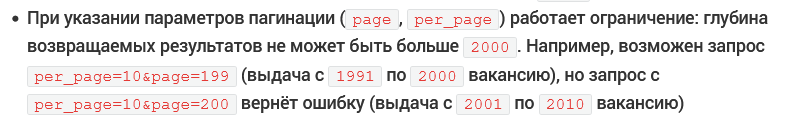

**Вопрос 2.** Какие навыки чаще всего встречаются в вакансиях по данной специальности?

Для этого найдите соответствующее поле в данных из полного описания вакансий, проанализируйте его и составьте список навыков и количество упоминаний каждого. Визуализируйте полученную информацию по топ-15 навыков.

За код опыта отвечает поле key_skills, однако навыки в том числе записывают в description и в name. Однако, я думаю, что сейчас хватит и key_skills. Собирать навыки из description проблематично.

<ipython-input-69-7deaab4b4da2>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


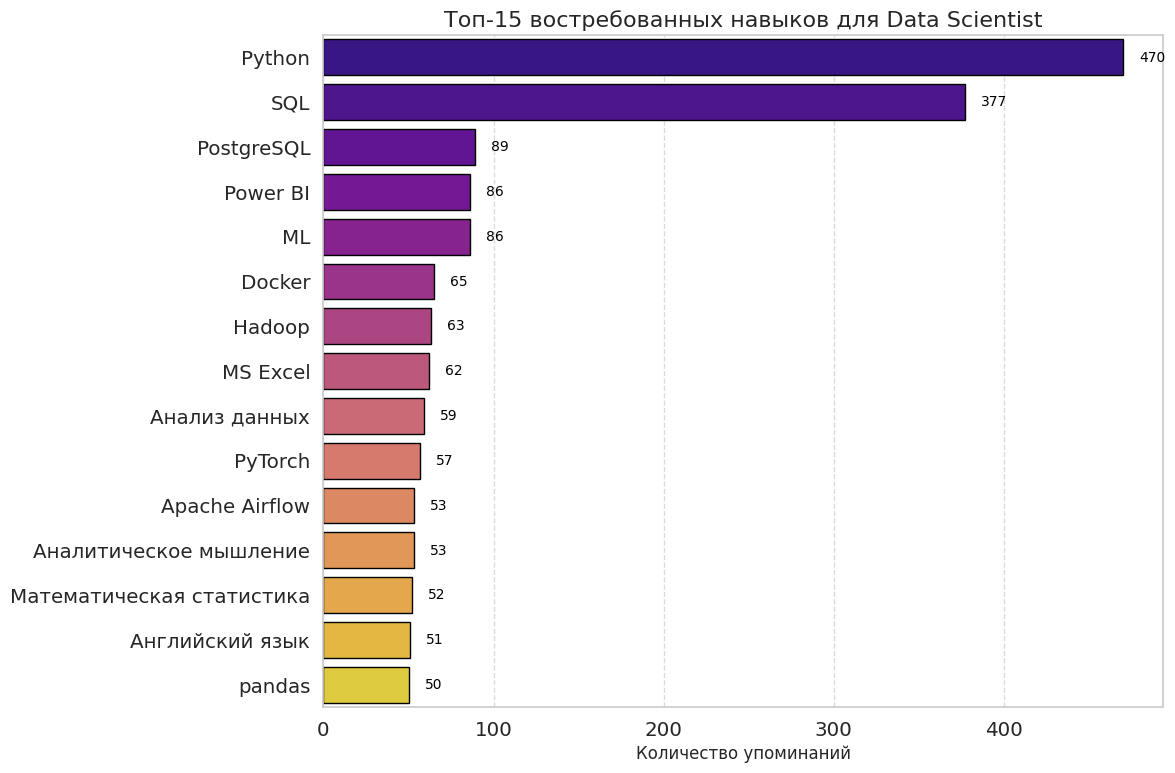

In [ ]:
# Извлечение навыков из списка словарей
enriched_df_csv['skills_list'] = enriched_df_csv['key_skills'].apply(
    lambda x: [skill['name'] for skill in x] if isinstance(x, list) else []
)

# Подсчет частоты навыков
skills_series = enriched_df_csv['skills_list'].explode()
skills_counts = skills_series.value_counts().reset_index()
skills_counts.columns = ['skill', 'count']

# Фильтрация топ-15 навыков
top_skills = skills_counts.head(15)

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(
    x='count',
    y='skill',
    data=top_skills,
    palette='plasma',
    edgecolor='black'
)

plt.title('Топ-15 востребованных навыков для Data Scientist', fontsize=16)
plt.xlabel('Количество упоминаний', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Добавление подписей
for i, (count, skill) in enumerate(zip(top_skills['count'], top_skills['skill'])):
    plt.text(
        x=count + max(top_skills['count'])*0.02,  # Отступ 2% от максимума
        y=i,
        s=f"{count}",
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

Странно, что нет "json" :)

**Вопрос 3.** Какую зарплату готовы платить работодатели? Соберите некоторым образом статистику и постройте гистограмму.

При работе с данными о заработной плате обратите внимание на валюту и <a target="_blank" href="https://yandex.ru/search/?text=gross%2Fnet&clid=1955455&win=446&lr=213&noreask=1">gross/net</a>. Постоянно подгружать курс валюты не требуется, достаточно фиксировать какой-то один более менее актуальный.

При наличии зарплатного диапазона берём меньшую зарплату, потому что эти цифры указываются больше для пиара. Да и разраб с большим опытом чаще договаривается лично насчет зарплаты.

Если указана нижняя граница, будем использовать её. Если указана только верхняя граница, будем использовать её, делённую на 3.

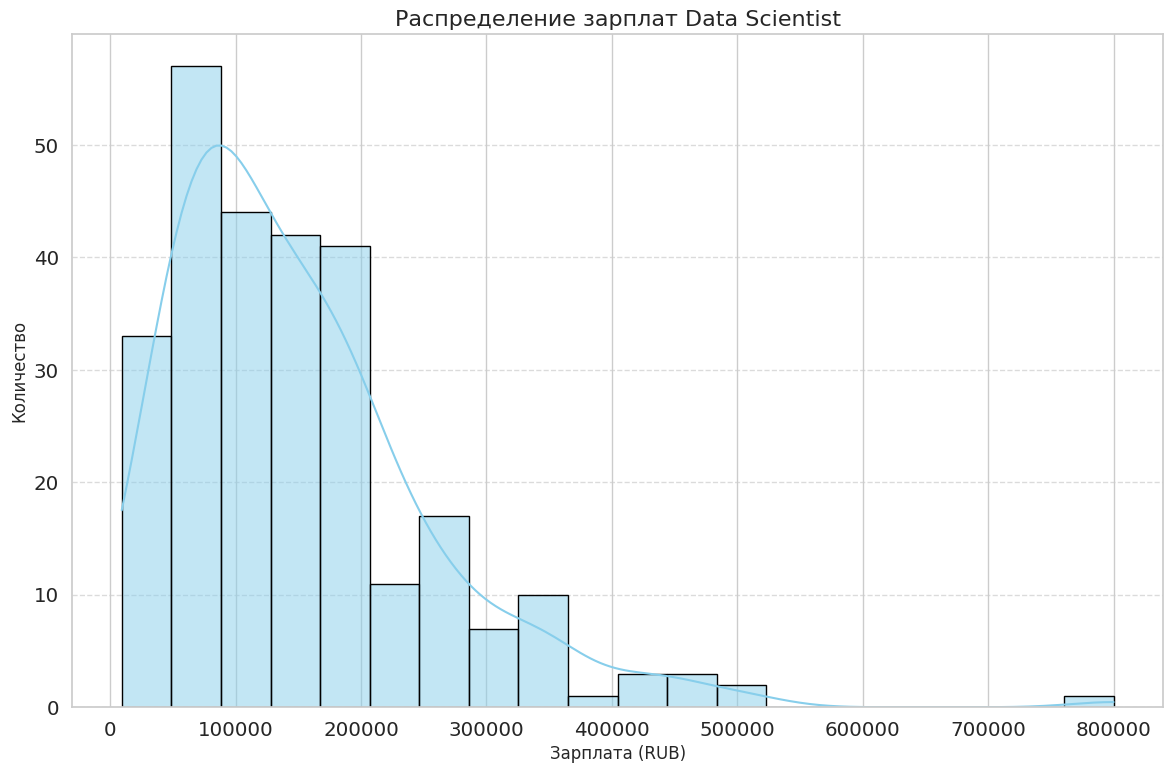

In [ ]:
# Фиксированный курс обмена
exchange_rates = {
    'USD': 90,
    'EUR': 100,
    'BYR': 0.3,  # 1 BYR = 0.3 RUB
    'RUR': 1    # 1 RUR = 1 RUB
}

# Коэффициенты для конвертации gross/net (примерные значения)
gross_to_net = 0.87

# Функция для конвертации валют в рубли с учетом типа зарплаты
def convert_to_rubles(row):
    salary_from = row['salary_from']
    salary_to = row['salary_to']
    currency = row['currency']
    gross_net = row['gross_net']

    if currency in exchange_rates:
        if pd.notna(salary_from):
            salary = salary_from
        elif pd.notna(salary_to):
            salary = salary_to / 3
        else:
            return None

        # Конвертация в рубли
        salary_rub = salary * exchange_rates[currency]

        # Учет типа зарплаты (gross/net)
        if gross_net == 'gross':
            salary_rub *= gross_to_net

        return salary_rub
    return None

# Применяем функцию конвертации
enriched_df_csv['salary_rub'] = enriched_df_csv.apply(convert_to_rubles, axis=1)

# Фильтрация данных (например, только зарплаты с указанной нижней или верхней границей)
salary_data = enriched_df_csv.dropna(subset=['salary_rub'])

# Построение гистограммы
plt.figure(figsize=(12, 8))
sns.histplot(salary_data['salary_rub'], bins=20, kde=True, color='skyblue', edgecolor='black')

plt.title('Распределение зарплат Data Scientist', fontsize=16)
plt.xlabel('Зарплата (RUB)', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Вопрос 4.** Какой формат работы предлагается (в офисе / удаленно / ...)?

ФОРМАТ РАБОТЫ:

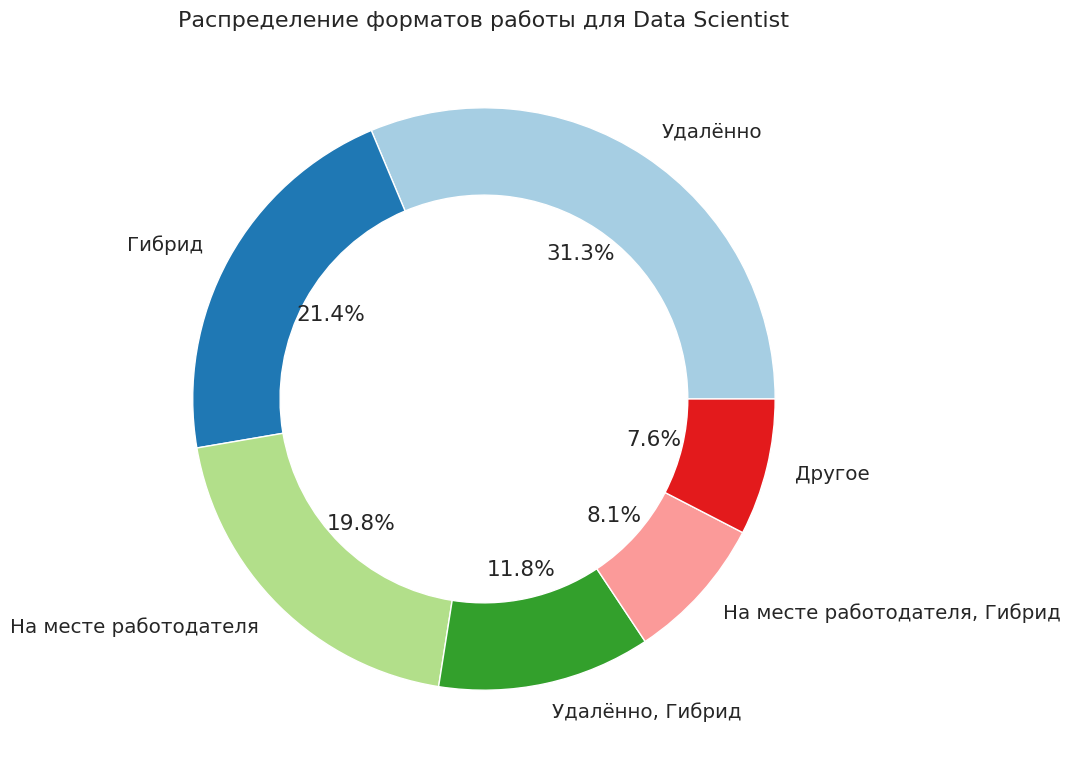

In [ ]:
# Загрузка данных из CSV
enriched_df_csv = pd.read_csv('detailed_vacancies_csv.csv')

# Извлечение данных о формате работы
work_format_series = enriched_df_csv['work_format'].explode()

# Подсчет частоты каждого формата работы
work_format_counts = work_format_series.value_counts()

# Определение порога для объединения категорий
threshold = 0.049 * len(work_format_series)

# Объединение категорий, которые составляют менее 4.9% от общего количества
other_category = work_format_counts[work_format_counts < threshold].sum()
work_format_counts = work_format_counts[work_format_counts >= threshold]
work_format_counts['Другое'] = other_category

# Построение круговой диаграммы
plt.figure(figsize=(10, 8))
work_format_counts.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, wedgeprops=dict(width=0.3))

plt.title('Распределение форматов работы для Data Scientist', fontsize=16)
plt.ylabel('')  # Убираем метку оси Y
plt.tight_layout()
plt.show()

ЧАСЫ РАБОТЫ:

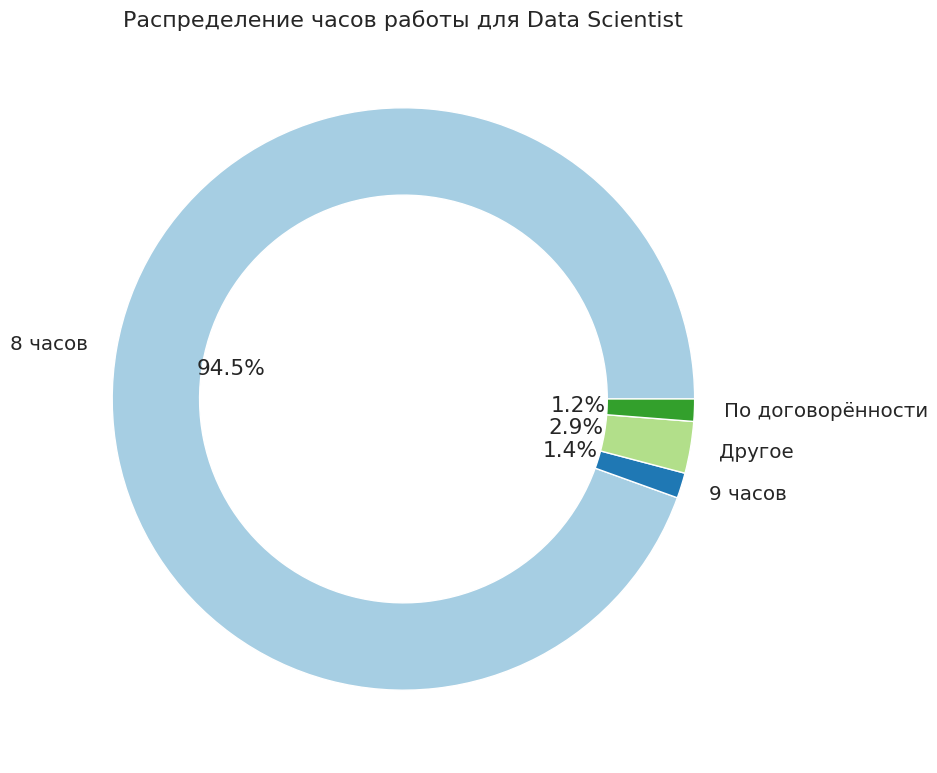

In [ ]:
# Извлечение данных о часах работы
working_hours_series = enriched_df_csv['working_hours'].explode()

# Подсчет частоты каждого варианта часов работы
working_hours_counts = working_hours_series.value_counts()

# Определение порога для объединения категорий
threshold = 0.009 * len(working_hours_series)

# Объединение категорий, которые составляют менее 0.9% от общего количества
other_category = working_hours_counts[working_hours_counts < threshold].sum()
working_hours_counts = working_hours_counts[working_hours_counts >= threshold]
working_hours_counts['Другое'] = other_category

# Построение круговой диаграммы
plt.figure(figsize=(10, 8))
working_hours_counts.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, wedgeprops=dict(width=0.3))

plt.title('Распределение часов работы для Data Scientist', fontsize=16)
plt.ylabel('')  # Убираем метку оси Y
plt.tight_layout()
plt.show()

ФОРМАТ РАБОТЫ ПО ДНЯМ:

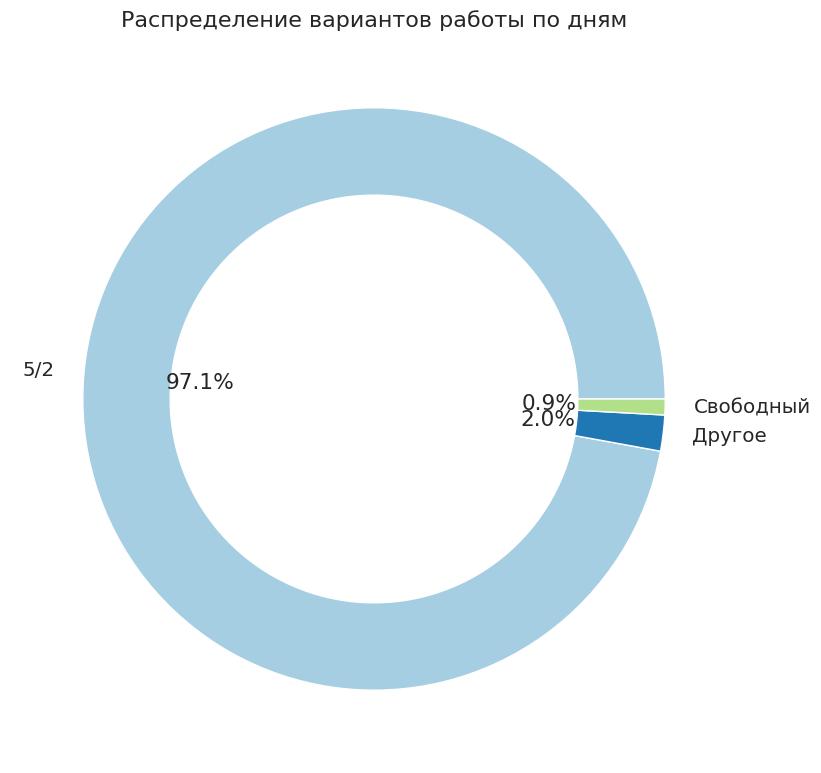

In [ ]:
# Извлечение данных о графике работы по дням
work_schedule_by_days_series = enriched_df_csv['work_schedule_by_days'].explode()

# Подсчет частоты каждого варианта графика работы по дням
work_schedule_by_days_counts = work_schedule_by_days_series.value_counts()

# Определение порога для объединения категорий
threshold = 0.008 * len(work_schedule_by_days_series)

# Объединение категорий, которые составляют менее 0.8% от общего количества
other_category = work_schedule_by_days_counts[work_schedule_by_days_counts < threshold].sum()
work_schedule_by_days_counts = work_schedule_by_days_counts[work_schedule_by_days_counts >= threshold]
work_schedule_by_days_counts['Другое'] = other_category

# Построение круговой диаграммы
plt.figure(figsize=(10, 8))
work_schedule_by_days_counts.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, wedgeprops=dict(width=0.3))

plt.title('Распределение вариантов работы по дням', fontsize=16)
plt.ylabel('')  # Убираем метку оси Y
plt.tight_layout()
plt.show()

Проведите аналогичный анализ для наиболее привлекательной для вас профессии в любом регионе. Если это Data Scientist, то для анализа выберите другую. В данном пункте спокойно можно сделать копипасту кода.

Посмотрим на вакансии курьеров в Москве

In [ ]:
def smart_search():
    url = "https://api.hh.ru/vacancies"

    # Упрощенный поисковый запрос
    params = {
        "text": 'NAME:("Курьер" OR "доставщик") OR DESCRIPTION:("Курьер" OR "доставщик")',
        "page": 0,
        'area': 1,
        "per_page": 100,
        "order_by": "publication_time"
    }

    all_vacancies = []

    while True:
        try:
            response = requests.get(url, params=params)
            response.raise_for_status()
            data = response.json()

            # Просто добавляем все полученные результаты
            all_vacancies.extend(data['items'])

            # Проверка последней страницы
            if params["page"] >= data["pages"] - 1 or len(all_vacancies) >= 1799:
                break

            params["page"] += 1

            # Случайная задержка
            time.sleep(random.uniform(1.0, 1.3))

        except Exception as e:
            print(f"Ошибка: {e}")
            break

    return pd.json_normalize(all_vacancies)

# Запуск и проверка
df = smart_search()

# Анализ результатов
print(f"Всего найдено: {len(df)}")
print("Топ-5 вакансий:")
print(df[['name', 'employer.name']].head())

Всего найдено: 1800
Топ-5 вакансий:
                                                name  \
0          Администратор в стоматологическую клинику   
1           Мобильный специалист по документообороту   
2                                  Менеджер доставки   
3                                             Курьер   
4  Администратор интернет - магазина (Шипиловская...   

                employer.name  
0             Гармония Улыбки  
1      Курьер Сервис Экспресс  
2   Цыкунов Артур Геннадьевич  
3                       СМАРТ  
4  Самокат (ООО Умный ритейл)  


In [ ]:
df = df.drop_duplicates(subset='id', keep='first')
print(f"Уникальных вакансий: {len(df)}")

Уникальных вакансий: 1798


In [ ]:
enriched_df_spb = enrich_vacancies_data(df)

# Сохранение результатов в csv
enriched_df_spb.to_csv('detailed_vacancies_del.csv', index=False, encoding='utf-8-sig')

# Пример данных
print(f"\nСобрано данных: {len(enriched_df_spb)} вакансий")
print("Структура данных:")
print(enriched_df_csv.dtypes)
print("\nПример записи:")
print(enriched_df_csv.iloc[0])

Обработка вакансий: 100%|██████████| 1798/1798 [20:52<00:00,  1.44шт/s]



Собрано данных: 1728 вакансий
Структура данных:
id                        object
name                      object
employer                  object
salary_from              float64
salary_to                float64
currency                  object
gross_net                 object
experience                object
schedule                  object
employment                object
skills                    object
description               object
metro_line                object
metro_station             object
published_at              object
url                       object
key_skills                object
work_format               object
working_days              object
working_hours             object
work_schedule_by_days     object
employment_form           object
skills_list               object
salary_rub               float64
dtype: object

Пример записи:
id                                                               119826698
name                                               Ста

In [ ]:
# Пример данных
print(f"\nСобрано данных: {len(enriched_df_spb)} вакансий")
print("Структура данных:")
print(enriched_df_csv.dtypes)
print("\nПример записи:")
print(enriched_df_csv.iloc[0])


Собрано данных: 1798 вакансий
Структура данных:
id                        object
name                      object
employer                  object
salary_from              float64
salary_to                float64
currency                  object
gross_net                 object
experience                object
schedule                  object
employment                object
skills                    object
description               object
metro_line                object
metro_station             object
published_at              object
url                       object
key_skills                object
work_format               object
working_days              object
working_hours             object
work_schedule_by_days     object
employment_form           object
skills_list               object
salary_rub               float64
dtype: object

Пример записи:
id                                                               119826698
name                                               Ста

<ipython-input-84-69146cb5e723>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


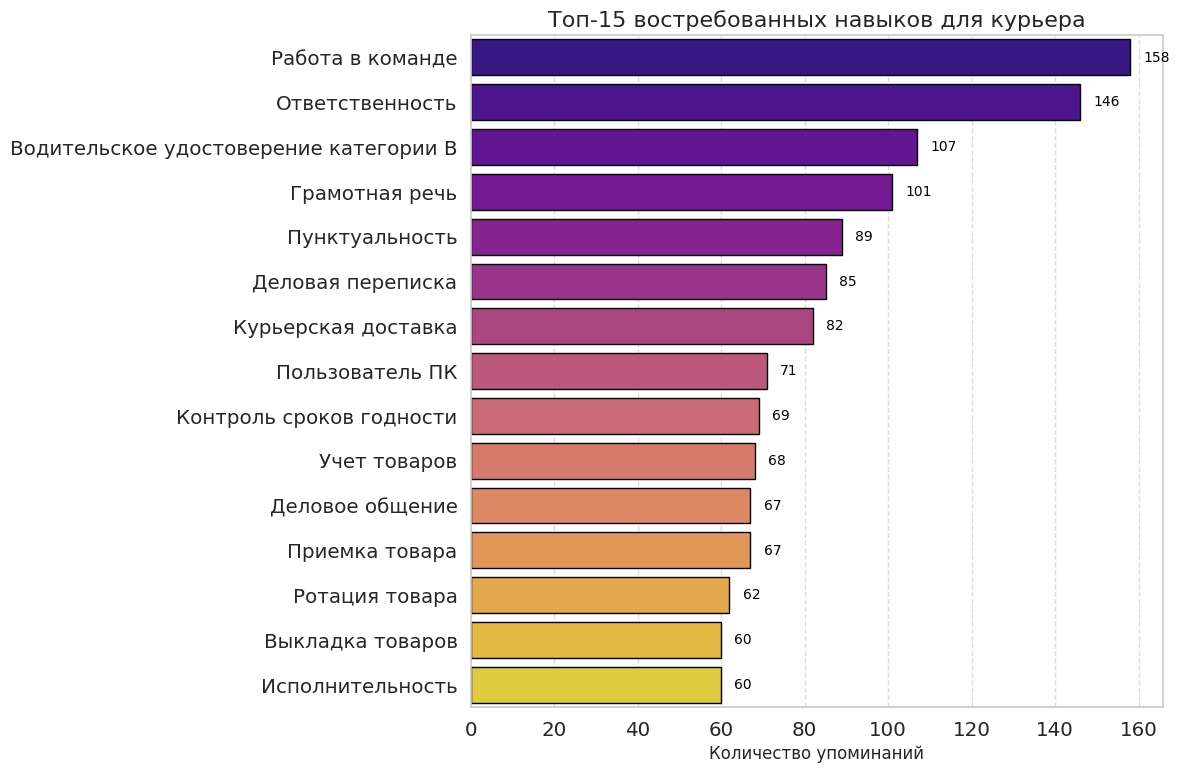

In [ ]:
# Извлечение навыков из списка словарей
enriched_df_spb['skills_list'] = enriched_df_spb['key_skills'].apply(
    lambda x: [skill['name'] for skill in x] if isinstance(x, list) else []
)

# 2. Подсчет частоты навыков
skills_series = enriched_df_spb['skills_list'].explode()
skills_counts = skills_series.value_counts().reset_index()
skills_counts.columns = ['skill', 'count']

# Фильтрация топ-15 навыков
top_skills = skills_counts.head(15)

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(
    x='count',
    y='skill',
    data=top_skills,
    palette='plasma',
    edgecolor='black'
)

plt.title('Топ-15 востребованных навыков для курьера', fontsize=16)
plt.xlabel('Количество упоминаний', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Добавление подписей
for i, (count, skill) in enumerate(zip(top_skills['count'], top_skills['skill'])):
    plt.text(
        x=count + max(top_skills['count'])*0.02,  # Отступ 2% от максимума
        y=i,
        s=f"{count}",
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

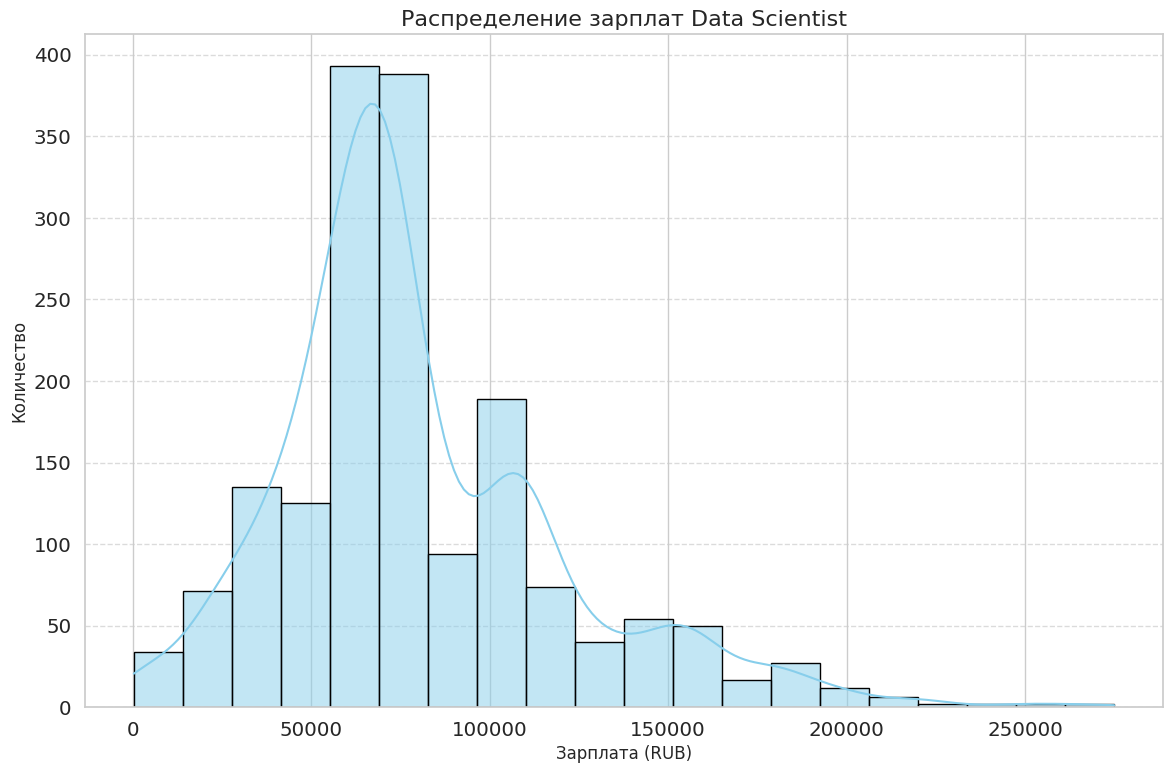

In [ ]:
# Фиксированный курс обмена
exchange_rates = {
    'USD': 90,
    'EUR': 100,
    'BYR': 0.3,  # 1 BYR = 0.3 RUB
    'RUR': 1    # 1 RUR = 1 RUB
}

# Коэффициенты для конвертации gross/net (примерные значения)
gross_to_net = 0.87

# Функция для конвертации валют в рубли с учетом типа зарплаты
def convert_to_rubles(row):
    salary_from = row['salary_from']
    salary_to = row['salary_to']
    currency = row['currency']
    gross_net = row['gross_net']

    if currency in exchange_rates:
        if pd.notna(salary_from):
            salary = salary_from
        elif pd.notna(salary_to):
            salary = salary_to / 3
        else:
            return None

        # Конвертация в рубли
        salary_rub = salary * exchange_rates[currency]

        # Учет типа зарплаты (gross/net)
        if gross_net == 'gross':
            salary_rub *= gross_to_net

        return salary_rub
    return None

# Применяем функцию конвертации
enriched_df_spb['salary_rub'] = enriched_df_spb.apply(convert_to_rubles, axis=1)

# Фильтрация данных (например, только зарплаты с указанной нижней или верхней границей)
salary_data = enriched_df_spb.dropna(subset=['salary_rub'])

# Построение гистограммы
plt.figure(figsize=(12, 8))
sns.histplot(salary_data['salary_rub'], bins=20, kde=True, color='skyblue', edgecolor='black')

plt.title('Распределение зарплат Data Scientist', fontsize=16)
plt.xlabel('Зарплата (RUB)', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

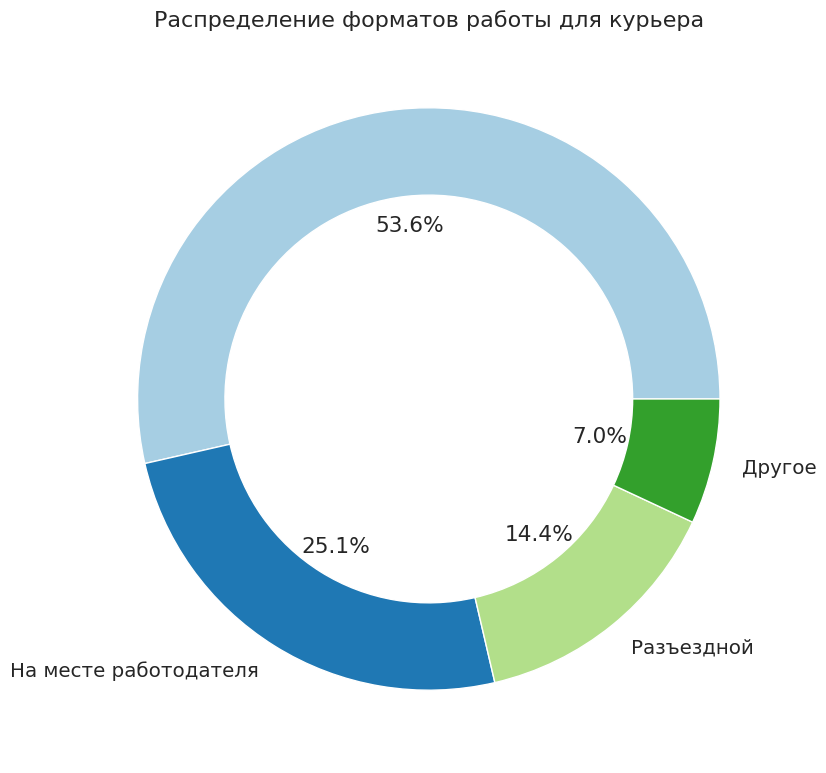

In [ ]:
# Извлечение данных о формате работы
work_format_series = enriched_df_spb['work_format'].explode()

# Подсчет частоты каждого формата работы
work_format_counts = work_format_series.value_counts()

# Определение порога для объединения категорий
threshold = 0.05 * len(work_format_series)

# Объединение категорий, которые составляют менее 5% от общего количества
other_category = work_format_counts[work_format_counts < threshold].sum()
work_format_counts = work_format_counts[work_format_counts >= threshold]
work_format_counts['Другое'] = other_category

# Построение круговой диаграммы
plt.figure(figsize=(10, 8))
work_format_counts.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, wedgeprops=dict(width=0.3))

plt.title('Распределение форматов работы для курьера', fontsize=16)
plt.ylabel('')  # Убираем метку оси Y
plt.tight_layout()
plt.show()

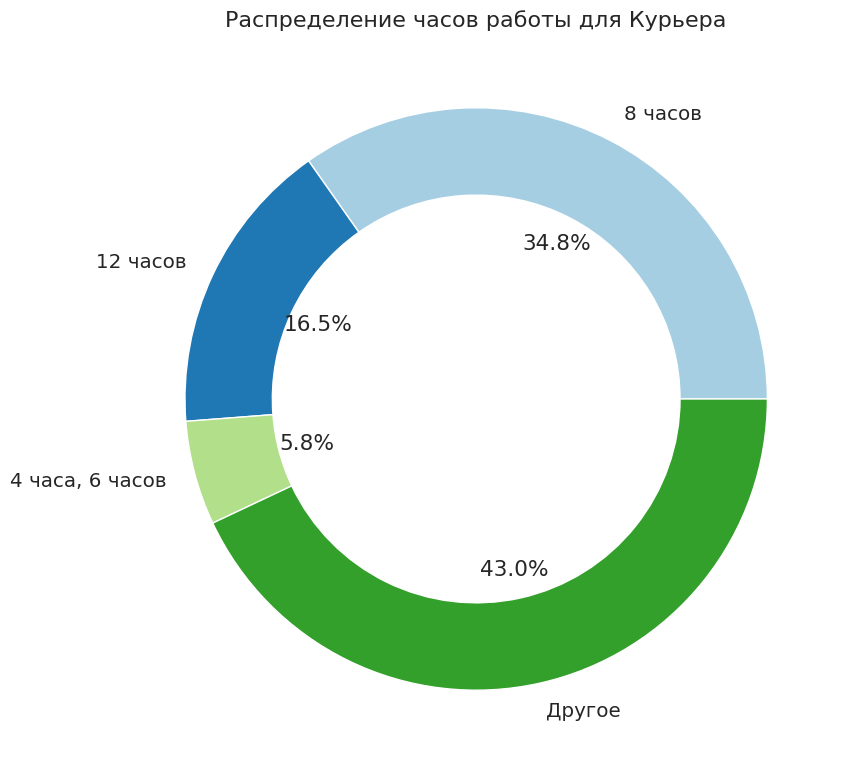

In [ ]:
# Извлечение данных о часах работы
working_hours_series = enriched_df_spb['working_hours'].explode()

# Подсчет частоты каждого варианта часов работы
working_hours_counts = working_hours_series.value_counts()

# Определение порога для объединения категорий
threshold = 0.05 * len(working_hours_series)

# Объединение категорий, которые составляют менее 5% от общего количества
other_category = working_hours_counts[working_hours_counts < threshold].sum()
working_hours_counts = working_hours_counts[working_hours_counts >= threshold]
working_hours_counts['Другое'] = other_category

# Построение круговой диаграммы
plt.figure(figsize=(10, 8))
working_hours_counts.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, wedgeprops=dict(width=0.3))

plt.title('Распределение часов работы для Курьера', fontsize=16)
plt.ylabel('')  # Убираем метку оси Y
plt.tight_layout()
plt.show()

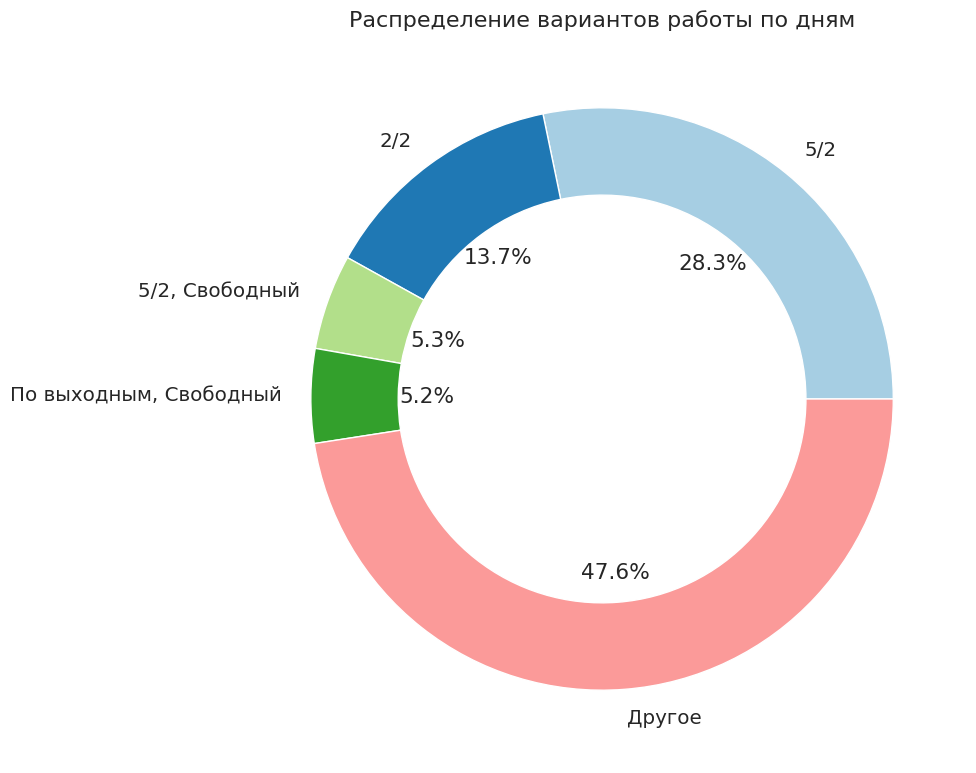

In [ ]:
# Извлечение данных о графике работы по дням
work_schedule_by_days_series = enriched_df_spb['work_schedule_by_days'].explode()

# Подсчет частоты каждого варианта графика работы по дням
work_schedule_by_days_counts = work_schedule_by_days_series.value_counts()

# Определение порога для объединения категорий
threshold = 0.05 * len(work_schedule_by_days_series)

# Объединение категорий, которые составляют менее 5% от общего количества
other_category = work_schedule_by_days_counts[work_schedule_by_days_counts < threshold].sum()
work_schedule_by_days_counts = work_schedule_by_days_counts[work_schedule_by_days_counts >= threshold]
work_schedule_by_days_counts['Другое'] = other_category

# Построение круговой диаграммы
plt.figure(figsize=(10, 8))
work_schedule_by_days_counts.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, wedgeprops=dict(width=0.3))

plt.title('Распределение вариантов работы по дням', fontsize=16)
plt.ylabel('')  # Убираем метку оси Y
plt.tight_layout()
plt.show()

Не забывайте про выводы.

Были проанализированы вакансии Data Science программиста и курьера в Москве. Вакансий курьеров больше. От разработчиков требуются конкретные прикладные навыки, такие как знания языков, в то время как от курьеров широко растяжимые понятия, человеческие качества. Зарплаты программистов больше, и к тому же у курьеров нет карьерного роста. В обоих случаях наблюдается значильно большее количество новичков по зарплате. У курьеров график более гибкий.

Если поинтересоваться у сми, то станет понятно, что на должность курьера берут любого, поэтому требования к их скиллам можно не читать. Кроме одного: хорошим плюсом будут права категории B.

В целом ожидается, что каждый программист знает python, SQL.

При выводе вакансий замечены несоответствия поисковым запросам. Это говорит о несовершенстве API.


---

### <font color="green"><i>Факультативная часть</i></font>

---

### Задача 2.   

Для *одной* из рассмотренных ранее профессий исследуйте, в каком районе Москвы данная вакансия пользуется наибольшим и наименьшим спросом.
Не забудьте про визуализацию, в частности, постройте распределений вакансий на карте.

*Напоминание.* Работа в некоторой степени творческая, поэтому конкретные детали решения в основном остаются на усмотрение автора решения.


In [ ]:
def smart_search():
    url = "https://api.hh.ru/vacancies"

    # Упрощенный поисковый запрос
    params = {
        "text": 'NAME:("дата аналитик" OR "Аналитик данных" OR "ML Engineer" OR "ML-инженер" OR "Data Scientist" OR "Data analyst") OR DESCRIPTION:("дата аналитик" OR ML* OR "ML Engineer" OR "ML-инженер" OR "Data Scientist" OR "Data analyst")',
        "page": 0,
        "area": 1,
        "per_page": 100,
        "order_by": "publication_time"
    }

    all_vacancies = []

    while True:
        try:
            response = requests.get(url, params=params)
            response.raise_for_status()
            data = response.json()

            # Просто добавляем все полученные результаты
            all_vacancies.extend(data['items'])

            # Проверка последней страницы
            if params["page"] >= data["pages"] - 1 or len(all_vacancies) >= 1799:
                break

            params["page"] += 1

            # Случайная задержка
            time.sleep(random.uniform(1.0, 1.3))

        except Exception as e:
            print(f"Ошибка: {e}")
            break

    return pd.json_normalize(all_vacancies)

# Запуск и проверка
df = smart_search()

# Анализ результатов
print(f"Всего найдено: {len(df)}")
print("Топ-5 вакансий:")
print(df[['name', 'employer.name']].head())

Всего найдено: 1745
Топ-5 вакансий:
                                          name employer.name
0                              Аналитик данных          СБЕР
1                           Системный аналитик          СБЕР
2               ML-разработчик в Город Шоппинг        Т-Банк
3  ML Engineer / Инженер по машинному обучению       Flowwow
4                              Аналитик данных       Parimir


In [ ]:
f = df.drop_duplicates(subset='id', keep='first')
print(f"Уникальных вакансий: {len(df)}")

Уникальных вакансий: 1745


In [ ]:
def get_vacancy_details(vacancy_id: str) -> dict:
    """Получение полного описания вакансии по ID"""
    url = f"https://api.hh.ru/vacancies/{vacancy_id}"
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Ошибка при получении вакансии {vacancy_id}: {str(e)}")
        return None

In [ ]:
def enrich_vacancies_data_upd(df: pd.DataFrame) -> pd.DataFrame:
    """Добавление подробной информации к данным о вакансиях"""
    enriched_data = []

    with tqdm(total=len(df), desc="Обработка вакансий", unit="шт") as pbar:
        for _, row in df.iterrows():
            try:
                vacancy_id = row['id']
                details = get_vacancy_details(vacancy_id)

                if not details:
                    continue

                # Безопасное извлечение данных о зарплате
                salary = details.get('salary') or {}
                address = details.get('address') or {}
                metro = address.get('metro') or {}

                # Извлечение данных о формате работы
                work_format = details.get('work_format', [])
                working_days = details.get('working_days', [])
                working_hours = details.get('working_hours', [])
                work_schedule_by_days = details.get('work_schedule_by_days', [])
                employment_form = details.get('employment_form', {})

                record = {
                    'id': vacancy_id,
                    'name': details.get('name'),
                    'employer': (details.get('employer') or {}).get('name'),
                    'salary_from': salary.get('from'),
                    'salary_to': salary.get('to'),
                    'currency': salary.get('currency'),
                    'gross_net': 'gross' if salary.get('gross') else 'net',
                    'experience': (details.get('experience') or {}).get('name'),
                    'schedule': (details.get('schedule') or {}).get('name'),
                    'employment': (details.get('employment') or {}).get('name'),
                    'skills': ', '.join([s['name'] for s in (details.get('key_skills') or [])]),
                    'description': details.get('description'),
                    'metro_line': metro.get('line_name'),
                    'metro_station': metro.get('station_name'),
                    'published_at': details.get('published_at'),
                    'url': details.get('alternate_url'),
                    'key_skills': details.get('key_skills'),
                    'work_format': ', '.join([f['name'] for f in work_format]),
                    'working_days': ', '.join([d['name'] for d in working_days]),
                    'working_hours': ', '.join([h['name'] for h in working_hours]),
                    'work_schedule_by_days': ', '.join([s['name'] for s in work_schedule_by_days]),
                    'employment_form': employment_form.get('name'),
                    'city': address.get('city'),
                    'street': address.get('street'),
                    'building': address.get('building'),
                    'lat': address.get('lat'),
                    'lng': address.get('lng'),
                    'address_id': address.get('id')
                }
                enriched_data.append(record)

            except Exception as e:
                print(f"\nОшибка в вакансии {vacancy_id}: {str(e)}")

            finally:
                time.sleep(0.05)
                pbar.update(1)

    return pd.DataFrame(enriched_data)

In [ ]:
enriched_df_new = enrich_vacancies_data_upd(df)

# Сохранение результатов в csv
enriched_df_new.to_csv('detailed_vacancies_new.csv', index=False, encoding='utf-8-sig')

Обработка вакансий: 100%|██████████| 1745/1745 [16:27<00:00,  1.77шт/s]


NameError: name 'enriched_df_csv' is not defined

In [ ]:
# Пример данных
print(f"\nСобрано данных: {len(enriched_df_new)} вакансий")
print("Структура данных:")
print(enriched_df_new.dtypes)
print("\nПример записи:")
print(enriched_df_new.iloc[0])


Собрано данных: 1745 вакансий
Структура данных:
id                        object
name                      object
employer                  object
salary_from              float64
salary_to                float64
currency                  object
gross_net                 object
experience                object
schedule                  object
employment                object
skills                    object
description               object
metro_line                object
metro_station             object
published_at              object
url                       object
key_skills                object
work_format               object
working_days              object
working_hours             object
work_schedule_by_days     object
employment_form           object
city                      object
street                    object
building                  object
lat                      float64
lng                      float64
address_id                object
dtype: object

Пример запис

Создадим интерактивную карту

In [ ]:
# Интерактивная карта с отмеченными адресами
m = folium.Map(location=[55.7558, 37.6173], zoom_start=10)

for _, row in enriched_df_new.iterrows():
    if pd.notna(row['lat']) and pd.notna(row['lng']):
        folium.Marker(
            location=[row['lat'], row['lng']],
            popup=f"{row['street']}, {row['building']}, {row['employer']}",
            icon=folium.Icon(color='blue')
        ).add_to(m)

m.save('interactive_map.html')

Неинтерактивную

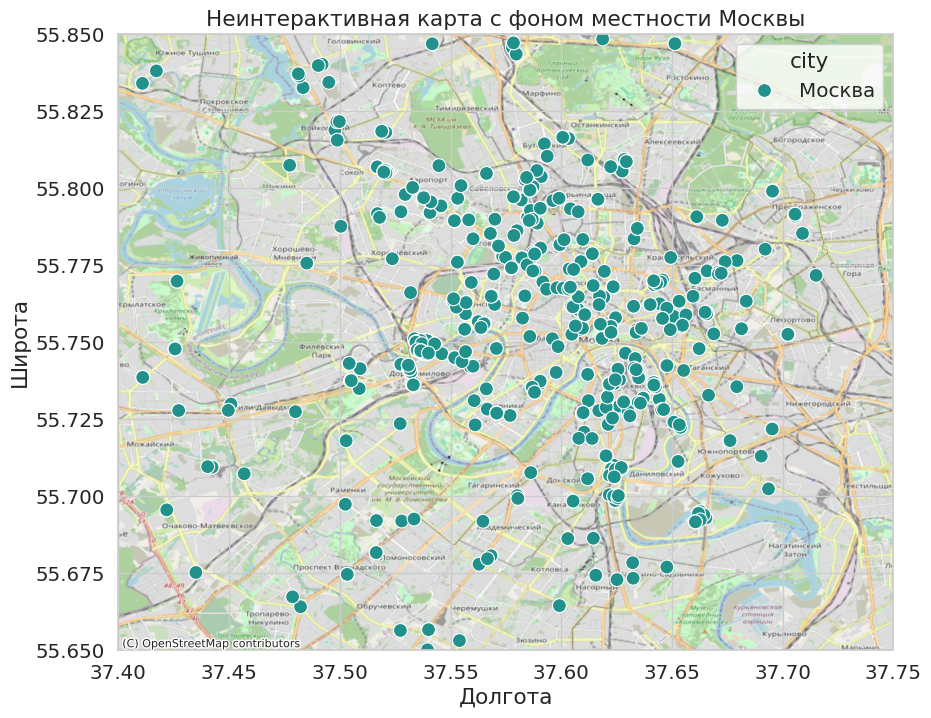

In [ ]:
# Фильтрация данных для Москвы
df_moscow = enriched_df_new[enriched_df_new['city'] == 'Москва']

# Ограничение диапазона координат для неинтерактивной карты
# Примерные координаты для небольшого диапазона от Москвы (включая МКАД)
lat_min, lat_max = 55.65, 55.85
lng_min, lng_max = 37.4, 37.75

# Фильтрация данных для неинтерактивной карты
df_moscow_small = df_moscow[(df_moscow['lat'] >= lat_min) & (df_moscow['lat'] <= lat_max) &
                             (df_moscow['lng'] >= lng_min) & (df_moscow['lng'] <= lng_max)]

#  Неинтерактивная карта с фоном местности Москвы
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_moscow_small, x='lng', y='lat', hue='city', palette='viridis', s=100)
plt.title('Неинтерактивная карта с фоном местности Москвы')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.xlim(lng_min, lng_max)
plt.ylim(lat_min, lat_max)
plt.grid(True)

# Добавление базовой карты местности Москвы
ctx.add_basemap(plt.gca(), source=ctx.providers.OpenStreetMap.Mapnik, crs='EPSG:4326')

plt.savefig('non_interactive_map.png', dpi=300, bbox_inches='tight')

plt.show()

Heat-map по количеству вакансий в районе

In [27]:
heat_data = [[row['lat'], row['lng']] for _, row in df_moscow.iterrows() if pd.notna(row['lat']) and pd.notna(row['lng'])]

m_heat = folium.Map(location=[55.7558, 37.6173], zoom_start=10)
HeatMap(heat_data).add_to(m_heat)

m_heat.save('heat_map.html')

NameError: name 'df_moscow' is not defined

In [34]:
display(IFrame('heat_map.html', width = 600, height = 600))

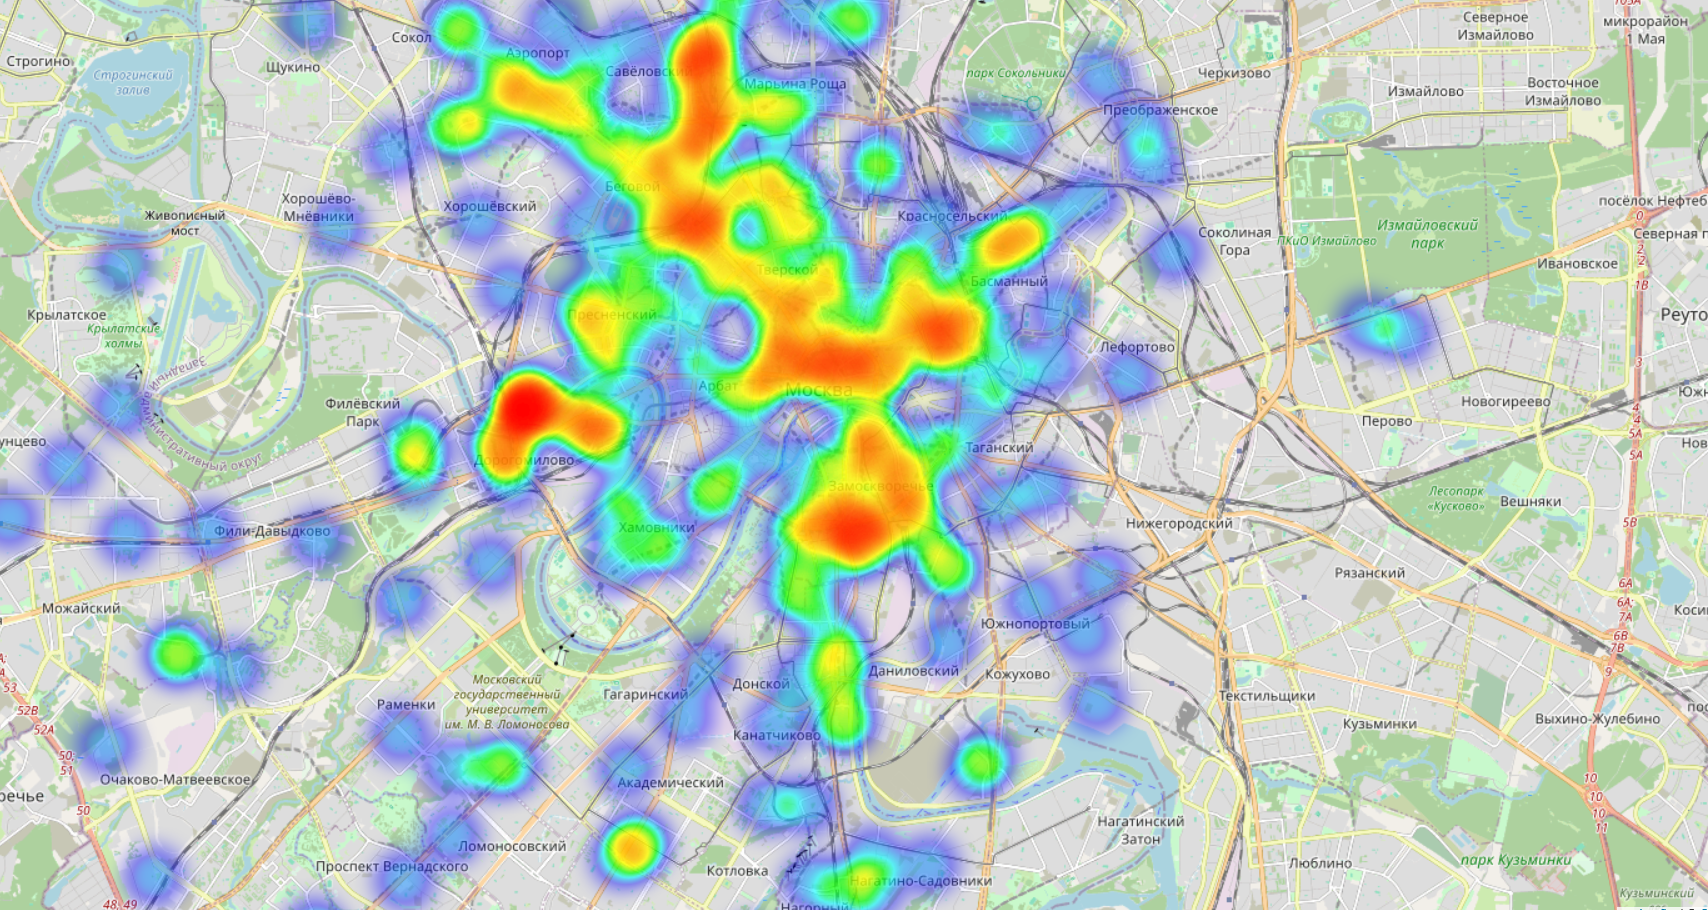

Какие выводы можно сделать из построенных графиков?

Некоторый работодатели указывают город Москва, хотя широта и долгота офиса далеко не Москва. В основном вакансии в центре и западнее. Наблюдается скопление в деловом центре.

---

### Задача 3.   

**1.** Проверьте, во скольких вакансиях среди выгруженных указана зарплата?


Используем метод notna() для проверки наличия значений в столбцах salary_from и salary_to. Если хотя бы одно из этих значений указано, то считаем, что зарплата указана.

In [20]:
# Загрузка данных из CSV файла
enriched_df_new = pd.read_csv('detailed_vacancies_new.csv')

# Проверка наличия зарплаты в вакансиях
vacancies_with_salary = enriched_df_new[enriched_df_new['salary_from'].notna() | enriched_df_new['salary_to'].notna()]

# Количество вакансий с указанной зарплатой
num_vacancies_with_salary = len(vacancies_with_salary)

print(f"Количество вакансий с указанной зарплатой: {num_vacancies_with_salary}")

Количество вакансий с указанной зарплатой: 275


На основе описания вакансий с известной зарплатой попробуйте оценить ожидаемую зарплату для всех остальных вакансий. Для этого на основе текстового описания вакансии можно построить эмбеддинги (любые подходящие нейросетевые или просто one-hot кодирование). По этим эмбеддингам обучите некоторую модель предсказывать зарплату.

Не забудьте по общий пайплайн ML-моделей, а также про применимость различных методов.

In [21]:
# Вычисление зарплаты для вакансий с вилкой
def calculate_salary(row):
    if pd.notna(row['salary_from']):
        return row['salary_from']
    elif pd.notna(row['salary_to']):
        return row['salary_to'] / 3
    else:
        return np.nan

In [22]:
# Разделение данных на вакансии без указанных зарплат

vacancies_without_salary = enriched_df_new[
    (enriched_df_new['salary_from'].isna() & enriched_df_new['salary_to'].isna())
]

vacancies_with_salary.loc[:, 'salary'] = vacancies_with_salary.apply(calculate_salary, axis=1)

<ipython-input-22-5e690c1c0b44>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vacancies_with_salary.loc[:, 'salary'] = vacancies_with_salary.apply(calculate_salary, axis=1)


In [23]:
# Подготовка данных для обучения модели
X_train = vacancies_with_salary['description']
y_train = vacancies_with_salary['salary']

# Создание пайплайна для преобразования текстовых данных в эмбеддинги и обучения модели
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('regressor', LinearRegression())
])

# Обучение модели
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=1000)),
                ('regressor', LinearRegression())])

<ipython-input-24-9b7e3f03316e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vacancies_without_salary.loc[:, 'predicted_salary'] = pipeline.predict(X_test)


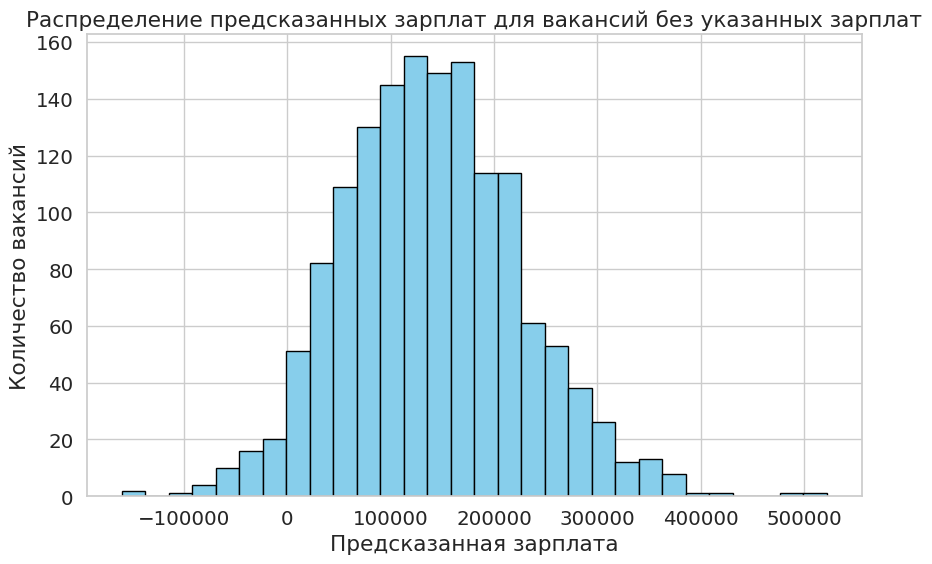

In [24]:
# Предсказание зарплаты для вакансий без указанных зарплат
X_test = vacancies_without_salary['description']
vacancies_without_salary.loc[:, 'predicted_salary'] = pipeline.predict(X_test)

# Визуализация распределения предсказанных зарплат
plt.figure(figsize=(10, 6))
plt.hist(vacancies_without_salary['predicted_salary'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение предсказанных зарплат для вакансий без указанных зарплат')
plt.xlabel('Предсказанная зарплата')
plt.ylabel('Количество вакансий')
plt.grid(True)
plt.show()

На отрицательные значения можно закрыть глаза

**2.** Выполните кластеризацию вакансий, используя построенные эмбеддинги. Визуализируйте результаты и проинтерпретируйте кластеры.

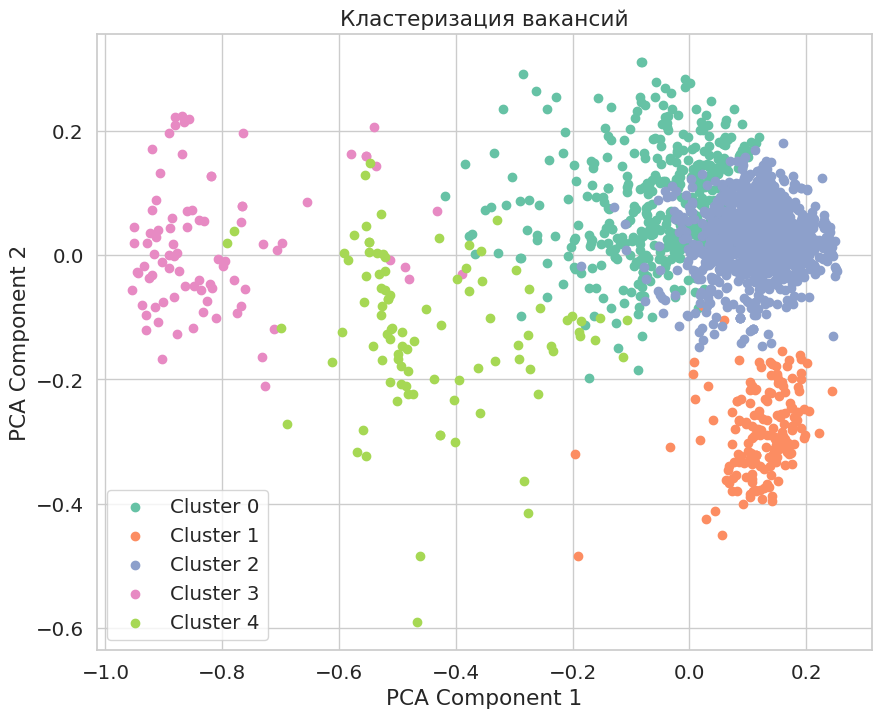

In [14]:
# Преобразование текстовых описаний вакансий в эмбеддинги
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(enriched_df_new['description'])

# Применение K-Means для кластеризации вакансий
num_clusters = 5  # Выберите количество кластеров
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
enriched_df_new['cluster'] = kmeans.fit_predict(X)

# Уменьшение размерности с использованием PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

# Визуализация результатов кластеризации
plt.figure(figsize=(10, 8))
for cluster in range(num_clusters):
    plt.scatter(X_pca[enriched_df_new['cluster'] == cluster, 0],
                X_pca[enriched_df_new['cluster'] == cluster, 1],
                label=f'Cluster {cluster}')

plt.title('Кластеризация вакансий')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

Проанализируем кластеры:

In [15]:
# Вывод нескольких описаний из каждого кластера
for cluster in range(num_clusters):
    print(f"\nCluster {cluster}:")
    cluster_descriptions = enriched_df_new[enriched_df_new['cluster'] == cluster]['description'].head(5)
    for desc in cluster_descriptions:
        print(desc)


Cluster 0:
<p><strong>Parimir</strong> – это особенное арт-пространство для парикмахеров и барберов.</p> <p>С 2016 года мы стремимся <em>не быть похожими на остальных</em> и идти своим путем.<br />Наш путь – это путь создания, а не копирования. Создания не только собственных брендов, но и уникальных систем управления, менеджмента и обучения.</p> <p>В 2018 году мы начали открывать свои шоу-румы. Их основное отличие – это место, которое диктует тренды. Мы производим, завозим и представляем самый широкий выбор эксклюзивных парикмахерских инструментов и аксессуаров для парикмахеров и барберов.</p> <p>Наша цель – стать самой крупной федеральной сетью шоу румов для парикмахеров в России и зарубежом. За счет профессионализма наших сотрудников и уникальных брендов.</p> <p><strong>Чем предстоит заниматься:</strong></p> <ul> <li> <p>Построение единого аналитического контура компании: от сбора данных до визуализации;</p> </li> <li> <p>Разработка <strong>регулярных отчетов и аналитических срезов<

С ходу выделяется кластер вакансий сбербанка. Также кластер 4 отличен от других указанием различных моделей в описании. Третий кластер включает в себя описание на английском. .....

А стоп. аххаахахаха. Походу он на спецсимволы смотрит: /li, /p, /strong, /br, ...

Не забывайте про выводы.

По указанным зарплатным диапазонам удалось предсказать довольно похожие на реальность зарплаты. Проведя кластеризацию, мною был обнаружен забавный факт, что нейросеть смотрит не на логику или контекст, а на знаки препинания, и мне кажется еще на манеру изложения. Однако, одно ключевое слово нейросеть уловила - это СБЕР.